# 03 — Feature Engineering + Baseline ML
## Dataset: Fraud detection 1M transactions

**Mục tiêu Phase 1**:
- Tạo feature bổ sung (đặc biệt graph-related)
- Train 3 baseline models: Logistic Regression → Random Forest → XGBoost/LightGBM
- Đánh giá đúng metrics cho fraud detection (PR-AUC, Recall, FPR…)
- Chọn model tốt nhất làm baseline production

## 0. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score
)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded.")

Libraries loaded.


In [2]:
DATA_DIR = Path("../data/processed/fraud_1m_processed")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Load dữ liệu đã clean
tx = pd.read_parquet(DATA_DIR / "transactions_clean.parquet")
edges = pd.read_parquet(DATA_DIR / "network_edges_clean.parquet")
accounts = pd.read_parquet(DATA_DIR / "account_profiles_clean.parquet")

print("transactions :", tx.shape)
print("network_edges:", edges.shape)
print("accounts     :", accounts.shape)
print("\nFraud rate  :", round(tx["is_fraud"].mean()*100, 3), "%")

transactions : (1000000, 23)
network_edges: (7411, 6)
accounts     : (50000, 23)

Fraud rate  : 1.714 %


## 1. Feature Engineering

### 1.1 Feature từ thời gian + flag

In [3]:
# is_night (tín hiệu mạnh từ EDA)
tx["is_night"] = tx["hour_of_day"].isin([0, 1, 2, 3, 4, 5]).astype("int8")

# High flags
tx["velocity_high"] = (tx["velocity_1h"] >= 5).astype("int8")
tx["ip_risk_high"] = (tx["ip_risk_score"] >= 50).astype("int8")
tx["amount_ratio_high"] = (tx["amount_vs_avg_ratio"] >= 5).astype("int8")

# Log amount
tx["amount_log"] = np.log1p(tx["amount"])

print("Đã tạo: is_night, velocity_high, ip_risk_high, amount_ratio_high, amount_log")

Đã tạo: is_night, velocity_high, ip_risk_high, amount_ratio_high, amount_log


### 1.2 Feature từ Graph (quan trọng)

In [4]:
# 1. in_ring
ring_accounts = set(edges.dropna(subset=["ring_id"])["account_a"]) | \
                set(edges.dropna(subset=["ring_id"])["account_b"])
tx["in_ring"] = tx["account_id"].isin(ring_accounts).astype("int8")

print(f"Số account trong ring: {len(ring_accounts):,}")
print(tx.groupby("in_ring")["is_fraud"].mean())

Số account trong ring: 6,783
in_ring
0    0.016156
1    0.022813
Name: is_fraud, dtype: float64


In [5]:
# 2. account_degree (số kết nối)
degree = pd.concat([edges["account_a"], edges["account_b"]]).value_counts()
tx["account_degree"] = tx["account_id"].map(degree).fillna(0).astype("int16")

print(tx["account_degree"].describe())

count    1000000.000000
mean           0.378203
std            1.476557
min            0.000000
25%            0.000000
50%            0.000000
75%            0.000000
max           21.000000
Name: account_degree, dtype: float64


In [6]:
# 3. shared_type count (số loại liên kết khác nhau của account)
# Tùy chọn - có thể bỏ nếu muốn đơn giản
shared_counts = edges.groupby("account_a")["shared_type"].nunique()
shared_counts = shared_counts.add(
    edges.groupby("account_b")["shared_type"].nunique(), fill_value=0
).astype(int)

tx["n_shared_types"] = tx["account_id"].map(shared_counts).fillna(0).astype("int8")
print(tx["n_shared_types"].value_counts().sort_index())

n_shared_types
0    851794
1    107340
2      7959
3      7303
4     10924
5      7528
6      5052
7      1384
8       716
Name: count, dtype: int64


### 1.3 Join thêm thông tin từ account_profiles

In [7]:
profile_cols = [
    "account_id", "risk_score", "is_high_risk", "fraud_rate",
    "avg_velocity", "pct_foreign", "is_fraudster", "avg_amount"
]
profile_cols = [c for c in profile_cols if c in accounts.columns]

tx = tx.merge(accounts[profile_cols], on="account_id", how="left", suffixes=("", "_profile"))

# Điền missing (nếu có)
for col in ["risk_score", "fraud_rate", "avg_velocity", "pct_foreign", "avg_amount"]:
    if col in tx.columns:
        tx[col] = tx[col].fillna(tx[col].median())

for col in ["is_high_risk", "is_fraudster"]:
    if col in tx.columns:
        tx[col] = tx[col].fillna(0).astype("int8")

print("Đã join account_profiles. Shape hiện tại:", tx.shape)

Đã join account_profiles. Shape hiện tại: (1000000, 38)


### 1.4 Chọn danh sách feature cuối cùng

In [8]:
FEATURE_COLS = [
    # Hành vi giao dịch
    "velocity_1h",
    "velocity_high",
    "amount",
    "amount_log",
    "amount_vs_avg_ratio",
    "amount_ratio_high",
    "time_since_last_s",
    "ip_risk_score",
    "ip_risk_high",
    
    # Thời gian
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "is_night",
    
    # Device / Transaction flag
    "is_foreign_txn",
    "card_present",
    "device_known",
    "has_2fa",
    
    # Account tĩnh (không phải historical fraud)
    "account_age_days",
    "credit_limit",
    
    # Graph (rất nên giữ)
    "in_ring",
    "account_degree",
    "n_shared_types",
    
    # Từ profile (chỉ giữ cái không leak)
    "avg_velocity",
    "pct_foreign",
]

# Chỉ giữ cột thực sự tồn tại
FEATURE_COLS = [c for c in FEATURE_COLS if c in tx.columns]
print(f"Số feature sử dụng: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Số feature sử dụng: 24
['velocity_1h', 'velocity_high', 'amount', 'amount_log', 'amount_vs_avg_ratio', 'amount_ratio_high', 'time_since_last_s', 'ip_risk_score', 'ip_risk_high', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_foreign_txn', 'card_present', 'device_known', 'has_2fa', 'account_age_days', 'credit_limit', 'in_ring', 'account_degree', 'n_shared_types', 'avg_velocity', 'pct_foreign']


In [9]:
# Kiểm tra missing trong feature
print(tx[FEATURE_COLS].isnull().sum().sort_values(ascending=False).head(10))

velocity_1h            0
velocity_high          0
amount                 0
amount_log             0
amount_vs_avg_ratio    0
amount_ratio_high      0
time_since_last_s      0
ip_risk_score          0
ip_risk_high           0
hour_of_day            0
dtype: int64


## 2. Train / Validation Split

In [10]:
X = tx[FEATURE_COLS].copy()
y = tx["is_fraud"].copy()

# Điền missing còn sót (nếu có)
X = X.fillna(X.median(numeric_only=True))

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Fraud rate:", round(y_train.mean()*100, 3), "%")
print("Val  :", X_val.shape,   "Fraud rate:", round(y_val.mean()*100, 3), "%")

Train: (800000, 24) Fraud rate: 1.714 %
Val  : (200000, 24) Fraud rate: 1.715 %


## 3. Hàm đánh giá chung

In [11]:
def evaluate_model(model, X_val, y_val, model_name="Model", threshold=0.5):
    """Đánh giá đầy đủ metrics cho fraud detection"""
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_prob = model.decision_function(X_val)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-8)

    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"\n{'='*50}")
    print(f" {model_name}")
    print(f"{'='*50}")
    print(f"ROC-AUC     : {roc_auc:.4f}")
    print(f"PR-AUC      : {pr_auc:.4f}   ← quan trọng nhất")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"F1-score    : {f1:.4f}")
    print(f"FPR         : {fpr:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"TN={tn:,}  FP={fp:,}")
    print(f"FN={fn:,}  TP={tp:,}")

    return {
        "model": model_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "y_prob": y_prob
    }

## 4. Model 2 — Random Forest

In [21]:
# 1. Tính toán trọng số dịu (Smoothed Weight)
raw_weight = (y_train == 0).sum() / (y_train == 1).sum()
smooth_weight = np.sqrt(raw_weight) # ~7.5

# 2. Khởi tạo Random Forest tối ưu cho Imbalanced Data
rf = RandomForestClassifier(
    n_estimators=300,                  # Tăng lên 300 cây để hội tụ ổn định hơn
    max_depth=14,                      # Tăng nhẹ độ sâu để bắt các luật phức tạp
    min_samples_split=20,              # Số lượng mẫu tối thiểu để tách nhánh
    min_samples_leaf=10,               # Giảm bớt min_samples_leaf từ 20 -> 10 để nhạy hơn với Fraud
    max_features="sqrt",               # Giảm ngẫu nhiên thuộc tính để chống overfit
    class_weight={0: 1.0, 1: smooth_weight}, # Trọng số tùy chỉnh dịu hơn
    random_state=42,
    n_jobs=-1
)

# 3. Fit mô hình
rf.fit(X_train, y_train)

# 4. Đánh giá sơ bộ
res_rf = evaluate_model(rf, X_val, y_val, "Random Forest")


 Random Forest
ROC-AUC     : 0.9927
PR-AUC      : 0.8340   ← quan trọng nhất
Precision   : 0.6439
Recall      : 0.8148
F1-score    : 0.7194
FPR         : 0.0079

Confusion Matrix:
TN=195,026  FP=1,545
FN=635  TP=2,794


## 5. Model 3 — XGBoost / LightGBM (mục tiêu chính)

In [15]:
from xgboost import XGBClassifier
# spw = (y_train == 0).sum() / (y_train == 1).sum()
# 1. Tính toán scale_pos_weight dạng Smoothed (dùng căn bậc 2)
raw_spw = (y_train == 0).sum() / (y_train == 1).sum()
spw = np.sqrt(raw_spw)  # Kết quả khoảng ~7.5 (Thay vì 57.3)
xgb = XGBClassifier(
    n_estimators=500,           # Tăng max trees, đã có early stopping quản lý
    max_depth=4,                # Giảm depth từ 6 xuống 4 để tránh học vẹt
    min_child_weight=10,        # Yêu cầu lá cây phải chứa đủ dữ liệu
    learning_rate=0.03,         # Hạ nhẹ learning rate để học kỹ hơn
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,       # Trọng số dịu hơn giúp cân bằng Precision/Recall
    reg_alpha=1.0,              # L1 Regularization
    reg_lambda=5.0,             # L2 Regularization
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50    # Tăng nhẹ rounds để tránh stop sớm ở dốc cục bộ
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

res_xgb = evaluate_model(xgb, X_val, y_val, "XGBoost")



[0]	validation_0-aucpr:0.68072
[50]	validation_0-aucpr:0.80344
[100]	validation_0-aucpr:0.81628
[150]	validation_0-aucpr:0.83004
[200]	validation_0-aucpr:0.83728
[250]	validation_0-aucpr:0.84187
[300]	validation_0-aucpr:0.84453
[350]	validation_0-aucpr:0.84584
[400]	validation_0-aucpr:0.84649
[450]	validation_0-aucpr:0.84655
[499]	validation_0-aucpr:0.84693

 XGBoost
ROC-AUC     : 0.9938
PR-AUC      : 0.8469   ← quan trọng nhất
Precision   : 0.5628
Recall      : 0.8667
F1-score    : 0.6824
FPR         : 0.0117

Confusion Matrix:
TN=194,262  FP=2,309
FN=457  TP=2,972


In [ ]:
# Feature importance của XGBoost
imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(imp.head(15))

ip_risk_score        0.320951
ip_risk_high         0.174901
velocity_1h          0.145176
velocity_high        0.138088
device_known         0.072412
is_foreign_txn       0.037574
amount               0.013025
amount_ratio_high    0.012518
is_night             0.010265
amount_log           0.009588
card_present         0.009260
account_degree       0.008375
hour_of_day          0.007374
n_shared_types       0.005457
has_2fa              0.005142
dtype: float32


## 6. So sánh tổng hợp

In [22]:
results = [res_rf,res_xgb]


df_results = pd.DataFrame(results)[["model", "roc_auc", "pr_auc", "precision", "recall", "f1", "fpr"]]
df_results = df_results.sort_values("pr_auc", ascending=False)

print("\n=== BẢNG SO SÁNH (sắp xếp theo PR-AUC) ===")
display(df_results.round(4))


=== BẢNG SO SÁNH (sắp xếp theo PR-AUC) ===


,model,roc_auc,pr_auc,precision,recall,f1,fpr
1,XGBoost,0.9938,0.8469,0.5628,0.8667,0.6824,0.0117
0,Random Forest,0.9927,0.8340,0.6439,0.8148,0.7194,0.0079


=== Random Forest Optimal Threshold ===
-> Threshold: 0.6719
-> Max F1    : 0.7570 (Precision: 0.7926, Recall: 0.7244)

=== XGBoost Optimal Threshold ===
-> Threshold: 0.8159
-> Max F1    : 0.7650 (Precision: 0.8011, Recall: 0.7320)



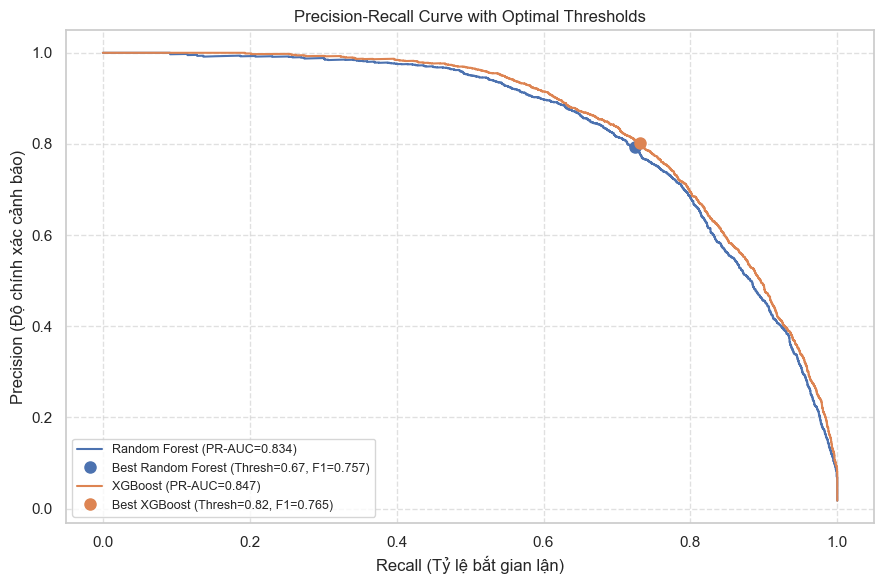

In [23]:
plt.figure(figsize=(9, 6))

best_thresholds = {}

for res in results:
    # 1. Tính Precision, Recall và Thresholds từ y_prob
    precisions, recalls, thresholds = precision_recall_curve(y_val, res["y_prob"])
    
    # 2. Tính F1-score cho mọi điểm Threshold (thêm 1e-10 để tránh chia cho 0)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # 3. Tìm chỉ số (index) có F1-score cao nhất
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    best_prec = precisions[best_idx]
    best_rec = recalls[best_idx]
    
    # Lưu lại threshold để dùng dự đoán sau này
    best_thresholds[res['model']] = best_thresh
    
    # In thông số chi tiết ra console
    print(f"=== {res['model']} Optimal Threshold ===")
    print(f"-> Threshold: {best_thresh:.4f}")
    print(f"-> Max F1    : {best_f1:.4f} (Precision: {best_prec:.4f}, Recall: {best_rec:.4f})\n")
    
    # 4. Vẽ đường Precision-Recall Curve
    line, = plt.plot(recalls, precisions, label=f"{res['model']} (PR-AUC={res['pr_auc']:.3f})")
    
    # 5. Đánh dấu điểm Optimal Threshold lên đường cong
    plt.plot(best_rec, best_prec, 'o', color=line.get_color(), markersize=8,
             label=f"Best {res['model']} (Thresh={best_thresh:.2f}, F1={best_f1:.3f})")

# Cấu hình biểu đồ
plt.xlabel("Recall (Tỷ lệ bắt gian lận)")
plt.ylabel("Precision (Độ chính xác cảnh báo)")
plt.title("Precision-Recall Curve with Optimal Thresholds")
plt.legend(loc="lower left", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 9. Feature Importance (model tốt nhất)

Best model: XGBoost


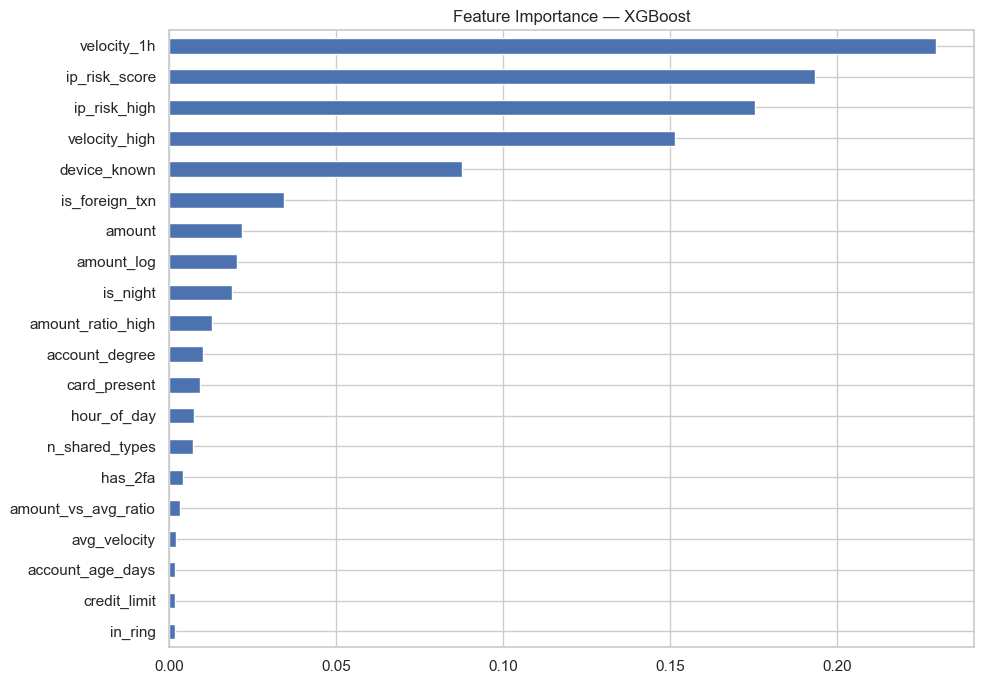


Top 15 features:
velocity_1h          0.229423
ip_risk_score        0.193408
ip_risk_high         0.175257
velocity_high        0.151369
device_known         0.087726
is_foreign_txn       0.034496
amount               0.021963
amount_log           0.020269
is_night             0.018800
amount_ratio_high    0.012959
account_degree       0.010033
card_present         0.009135
hour_of_day          0.007315
n_shared_types       0.007218
has_2fa              0.004055
dtype: float32


In [24]:
best_model = None
best_name = ""

if res_xgb is not None and res_xgb["pr_auc"] >= res_rf["pr_auc"]:
    best_model = xgb 
    best_name = "XGBoost" 
else:
    best_model = rf
    best_name = "Random Forest"

print(f"Best model: {best_name}")

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    imp = imp.sort_values(ascending=False)

    plt.figure(figsize=(10, 7))
    imp.head(20).plot(kind="barh")
    plt.title(f"Feature Importance — {best_name}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nTop 15 features:")
    print(imp.head(15))

## 8. Lưu model tốt nhất (tùy chọn)

In [25]:
import joblib


joblib.dump(best_model, MODEL_DIR / f"baseline_{best_name.lower().replace(' ', '_')}.pkl")
joblib.dump(FEATURE_COLS, MODEL_DIR / "feature_cols.pkl")
print("Đã lưu model và feature list")

Đã lưu model và feature list
